# Trabajo Práctico 2 - Visión por Computadora

Integrantes:
- Matías Guillermo Alfaro
- Rodrigo Hernández
- Gonzalo Cuervo
- Nicolas Alberto Tonnelier
- Marina Andrea Racciatti

# Objetivo:
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las  cámaras digitales modernas. El video a procesar será: “focus_video.mov”.

## 1.
Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain“ y realizar dos experimentos:

### 1.1
Medición sobre todo el frame.

### 2.1
Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.

Para cada experimento se debe presentar una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto la región de máximo enfoque.

El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera automática.

Puntos extra: Aplicar unsharp masking para expandir la zona de enfoque y devolver.

Matriz de enfoque superpuesta a uno de los frames del video:

![Matriz de enfoque en un frame 1](recursos/matriz-de-enfoque-en-un-frame-1.png)

![Matriz de enfoque en un frame 2](recursos/matriz-de-enfoque-en-un-frame-2.png)

*Notas de la clase a tener en cuenta:*
- *En el TP solo tenemos que usar un cuadradito verde. No se permite buscar el maximo y definirlo como el punto.*
- *En la sección de puntos extra no se permite aplicar unsharp masking a todo, de debe aplicar en la región frontera y deberíamos ver que se ensanche.*

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [2]:
def mostrar_imagen(imagen, titulo=""):
    # Helper para mostrar un frame BGR de OpenCV inline con matplotlib
    plt.figure(figsize=(10, 6))
    plt.imshow(cv.cvtColor(imagen, cv.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis("off")
    plt.show()

In [3]:
# Ejercicio 1: Algoritmo Image Sharpness Measure for Blurred Images in Frequency Domain

# Entrada: Imagen I de tamaño M×N.
# Salida: Medida de calidad de imagen (FM), donde FM significa Frequency Domain Image Blur Measure
def image_sharpness_measure(img):
    # La métrica opera sobre una imagen de un solo canal, así que primero pasamos los frames a color a escala de grises.
    if img.ndim == 3:
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    m_rows, n_cols = img.shape

    # Paso 1: Calcular F, la representación en Transformada de Fourier de la imagen I
    f = np.fft.fft2(img)

    # Paso 2: Obtener Fc desplazando el origen de F al centro.
    fc = np.fft.fftshift(f)

    # Paso 3: Calcular AF = abs(Fc), el valor absoluto de la Transformada de Fourier centrada de la imagen I.
    af = np.absolute(fc)

    # Paso 4: Calcular M = max(AF), el valor máximo de la componente de frecuencia en F.
    m = af.max()

    # Paso 5: Calcular TH = cantidad total de píxeles en F cuyo valor > thres, donde thres = M/1000.
    thres = m / 1000
    th = np.count_nonzero(af > thres)

    # Paso 6: Calcular la medida de calidad de imagen (FM) según la ecuación th/(M*N), donde M*N son las dimensiones de la imagen
    fm = th / (m_rows * n_cols)

    return fm

In [5]:
# Ejercicio 1.1: Aplicar el algoritmo al video sobre todo el frame

video_path = "recursos/focus_video.mov"
video = cv.VideoCapture(video_path)

if not video.isOpened():
    raise FileNotFoundError(f"No se pudo abrir {video_path}")

fm_scores = []
try:
    fps = video.get(cv.CAP_PROP_FPS)
    ret, frame = video.read()
    while ret:
        fm_scores.append(image_sharpness_measure(frame))
        ret, frame = video.read()
finally:
    video.release()

fm_scores = np.array(fm_scores)
print(f"Frames procesados: {len(fm_scores)} a {fps:.2f} fps")

Frames procesados: 171 a 29.97 fps


### Detección automática de la zona de máximo enfoque

La consigna pide devolver los puntos de máximo enfoque de manera automática, y la nota de clase aclara que **no se permite tomar el máximo de la curva y definirlo como el punto**. El motivo se ve en la curva: alrededor del pico hay un *plateau* de varios frames con valores de FM prácticamente equivalentes (la diferencia entre ellos es ruido, no enfoque). Elegir el `argmax` sería quedarse con un frame arbitrario de ese conjunto.

El criterio que usamos, entonces, tiene dos etapas:

1. **Zona en foco por umbral relativo.** Marcamos como "en foco" todo frame con `FM >= rel_threshold * max(FM)`. El máximo se usa solo para *normalizar* la escala de la métrica (que depende del contenido de la escena), no para elegir el punto.
2. **Punto representativo por centro de masa.** Dentro del tramo contiguo más largo de frames en foco, calculamos el centroide ponderado por FM. El resultado depende de la *forma* de todo el plateau, no de qué frame puntual sacó el valor más alto.

Devolvemos el tramo completo (que es "la región de máximo enfoque" que pide la consigna) y además ese punto único representativo.

In [6]:
def detect_focus_region(scores, rel_threshold=0.95):
    """
    Detecta automáticamente la región de máximo enfoque en una serie de métricas FM.

    Parámetros
    ----------
    scores : array_like
        Métrica FM por frame.
    rel_threshold : float
        Fracción del FM máximo a partir de la cual un frame se considera en foco.

    Retorna
    -------
    (start, end, representative) : tuple[int, int, int]
        Primer y último frame de la zona de máximo enfoque, y el frame
        representativo (centro de masa de la zona ponderado por FM).
    """
    scores = np.asarray(scores, dtype=float)
    if scores.size == 0:
        raise ValueError("No hay métricas para analizar")

    # Frames en foco: umbral relativo al máximo (el máximo normaliza, no elige el punto)
    in_focus = np.flatnonzero(scores >= rel_threshold * scores.max())

    # Tramo contiguo más largo (descarta picos aislados de ruido)
    runs = np.split(in_focus, np.flatnonzero(np.diff(in_focus) > 1) + 1)
    run = max(runs, key=len)

    # Frame representativo: centro de masa del tramo ponderado por FM
    representative = int(round(np.average(run, weights=scores[run])))

    return int(run[0]), int(run[-1]), representative


start, end, representative = detect_focus_region(fm_scores)

print(f"Zona de máximo enfoque: frames {start}-{end} ({(end - start + 1) / fps:.2f} s)")
print(f"Frame representativo:   {representative} (FM = {fm_scores[representative]:.5f})")

Zona de máximo enfoque: frames 105-113 (0.30 s)
Frame representativo:   109 (FM = 0.02862)


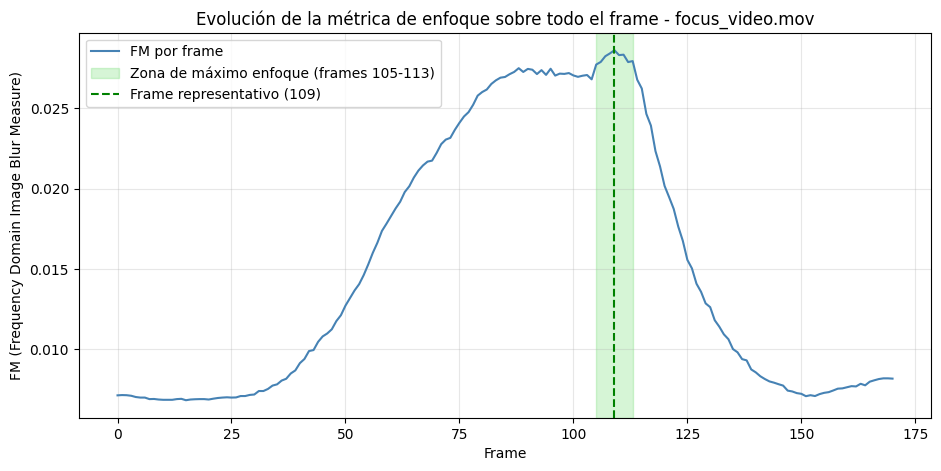

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(fm_scores, color="steelblue", label="FM por frame")
ax.axvspan(start, end, color="limegreen", alpha=0.2,
           label=f"Zona de máximo enfoque (frames {start}-{end})")
ax.axvline(representative, color="green", linestyle="--",
           label=f"Frame representativo ({representative})")

ax.set_xlabel("Frame")
ax.set_ylabel("FM (Frequency Domain Image Blur Measure)")
ax.set_title("Evolución de la métrica de enfoque sobre todo el frame - focus_video.mov")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

In [8]:
# Verificación del detector

# Sobre una curva sintética con plateau ruidoso: el pico absoluto está en el frame 2,
# pero el centro de masa de la zona en foco (frames 2-4) cae en el 3.
assert detect_focus_region([0.1, 0.1, 1.00, 0.98, 0.99, 0.1, 0.1]) == (2, 4, 3)

# El umbral no debe cambiar la conclusión: 0.95 y 0.98 tienen que coincidir en el frame representativo.
assert detect_focus_region(fm_scores, 0.95)[2] == detect_focus_region(fm_scores, 0.98)[2]

print("OK")

OK


### Observaciones

La curva muestra con claridad el barrido de foco del video, sobre 171 frames a 29.97 fps (≈5.7 s):

- **Frames 0-30 (desenfocado):** FM se mantiene plano en ≈0.0066, su valor mínimo. Con la escena fuera de foco el espectro concentra la energía en las bajas frecuencias y casi ningún coeficiente supera el umbral `M/1000`.
- **Frames 30-80 (entrando en foco):** FM crece de forma monótona y cruza la mitad de su rango en el frame 59. A medida que el objetivo enfoca aparecen bordes, y con ellos componentes de alta frecuencia que se cuentan como coeficientes por encima del umbral.
- **Frames 105-113 (máximo enfoque):** la zona detectada automáticamente, con FM máximo de 0.0278 en el frame representativo 109. Entre el mínimo y el máximo, FM varía por un factor de **4.2×**, un margen amplio: la métrica discrimina enfoque muy bien sin necesidad de suavizar la curva.
- **Frames 115-150 (saliendo de foco):** FM vuelve al nivel de base, confirmando que el video es un barrido de foco completo que pasa por el punto óptimo y sigue de largo. La caída es más abrupta que la subida (≈35 frames contra ≈50): la curva no es simétrica respecto del pico, el barrido no recorre el foco a velocidad constante.

Sobre la detección: el resultado es estable frente al umbral elegido. Con `rel_threshold` = 0.95 y 0.98 el frame representativo es el mismo (109), lo que indica que no estamos ajustando el parámetro para que dé un número lindo. Con 0.90 la zona se ensancha a los frames 80-115 y el centro de masa se corre al 98, porque a ese nivel el umbral ya entra en la pendiente de subida, donde la curva es asimétrica. Por eso 0.95 es una elección razonable: recorta el plateau sin comerse las rampas.

Vale notar una limitación del experimento sobre **todo el frame**: la métrica devuelve un único número por frame, así que dice *cuándo* el video está más enfocado pero no *qué parte* de la escena lo está. Si la escena tuviera objetos a distintas profundidades, el máximo global sería un promedio entre ellos. Eso es justamente lo que motiva el experimento siguiente, midiendo sobre una ROI.

## 2.1 - Medición sobre una ROI central

El experimento del 1.1 midió sobre todo el frame; acá restringimos la métrica a una **ROI central** cuya área es el **10% del frame**. Es el "cuadradito verde": una única región de enfoque, del mismo estilo que las celdas de la matriz de enfoque de una cámara, pero una sola (como aclara la nota de clase).

Reutilizamos la misma métrica `image_sharpness_measure` y el mismo detector `detect_focus_region`; lo único que cambia es que ahora los alimentamos con FM medido **solo dentro de la ROI**.

In [9]:
# Ejercicio 2.1: Medición sobre una ROI central (10% del área del frame)

ROI_AREA_FRACTION = 0.10  # área de la ROI relativa al frame


def central_roi_bounds(height, width, area_fraction=ROI_AREA_FRACTION):
    # Lado de la ROI = raíz de la fracción de área, para que el recuadro conserve la proporción del frame
    scale = np.sqrt(area_fraction)
    roi_h, roi_w = int(round(height * scale)), int(round(width * scale))
    y0 = (height - roi_h) // 2
    x0 = (width - roi_w) // 2
    return y0, x0, roi_h, roi_w


# El área de la ROI debe rondar la fracción pedida
_y0, _x0, _rh, _rw = central_roi_bounds(360, 640)
assert abs((_rh * _rw) / (360 * 640) - ROI_AREA_FRACTION) < 0.01

video = cv.VideoCapture(video_path)
if not video.isOpened():
    raise FileNotFoundError(f"No se pudo abrir {video_path}")

fm_scores_roi = []
try:
    ret, frame = video.read()
    frame_h, frame_w = frame.shape[:2]
    y0, x0, roi_h, roi_w = central_roi_bounds(frame_h, frame_w)
    while ret:
        roi = frame[y0:y0 + roi_h, x0:x0 + roi_w]
        fm_scores_roi.append(image_sharpness_measure(roi))
        ret, frame = video.read()
finally:
    video.release()

fm_scores_roi = np.array(fm_scores_roi)
start_roi, end_roi, representative_roi = detect_focus_region(fm_scores_roi)

print(f"ROI central: {roi_w}x{roi_h} px ({roi_w * roi_h / (frame_w * frame_h):.1%} del frame)")
print(f"Zona de máximo enfoque (ROI): frames {start_roi}-{end_roi} ({(end_roi - start_roi + 1) / fps:.2f} s)")
print(f"Frame representativo (ROI):   {representative_roi} (FM = {fm_scores_roi[representative_roi]:.5f})")

ROI central: 202x114 px (10.0% del frame)
Zona de máximo enfoque (ROI): frames 109-113 (0.17 s)
Frame representativo (ROI):   111 (FM = 0.35939)


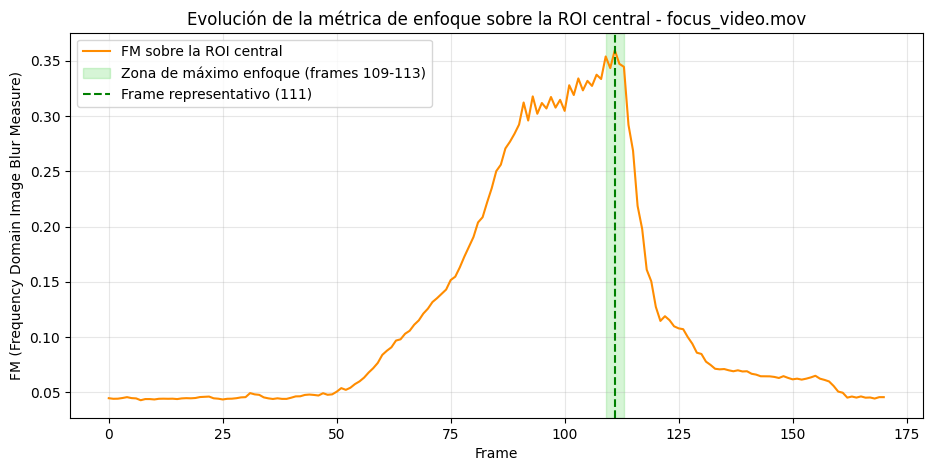

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(fm_scores_roi, color="darkorange", label="FM sobre la ROI central")
ax.axvspan(start_roi, end_roi, color="limegreen", alpha=0.2,
           label=f"Zona de máximo enfoque (frames {start_roi}-{end_roi})")
ax.axvline(representative_roi, color="green", linestyle="--",
           label=f"Frame representativo ({representative_roi})")

ax.set_xlabel("Frame")
ax.set_ylabel("FM (Frequency Domain Image Blur Measure)")
ax.set_title("Evolución de la métrica de enfoque sobre la ROI central - focus_video.mov")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

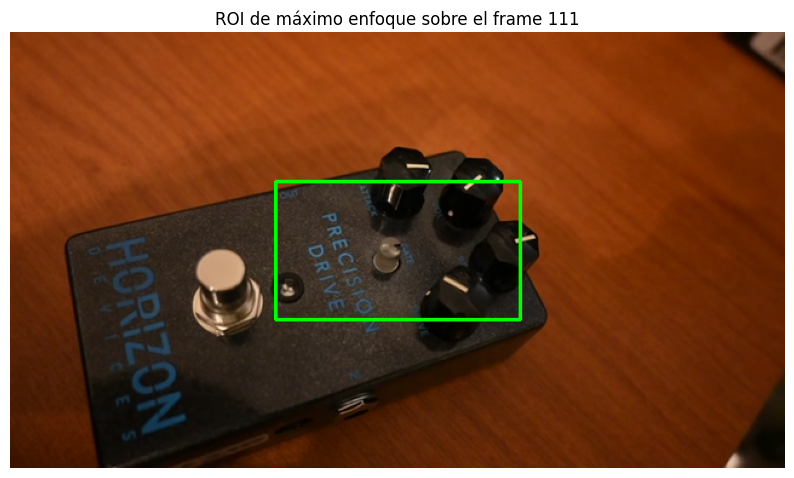

In [12]:
# Cuadradito verde: la ROI dibujada sobre el frame de máximo enfoque
video = cv.VideoCapture(video_path)
video.set(cv.CAP_PROP_POS_FRAMES, representative_roi)
ret, frame = video.read()
video.release()

vis = frame.copy()
cv.rectangle(vis, (x0, y0), (x0 + roi_w, y0 + roi_h), (0, 255, 0), 2)

mostrar_imagen(vis, titulo=f"ROI de máximo enfoque sobre el frame {representative_roi}")

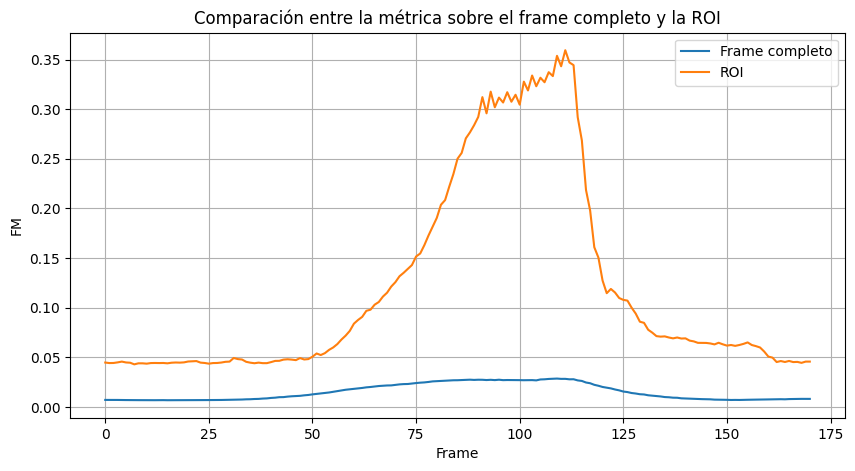

In [14]:
plt.figure(figsize=(10,5))

plt.plot(fm_scores, label="Frame completo")
plt.plot(fm_scores_roi, label="ROI")

plt.xlabel("Frame")
plt.ylabel("FM")
plt.title("Comparación entre la métrica sobre el frame completo y la ROI")
plt.legend()
plt.grid(True)

plt.show()

### Observaciones

Medida sobre la ROI central (10% del área, 202×114 px), el detector ubica la zona de máximo enfoque en los **frames 109-113** (representativo **111**), un poco más tardía y más angosta que sobre todo el frame (105-113, representativo 109).

La diferencia más notable es el **contraste de la métrica**: sobre la ROI, FM varía por un factor de **≈8.3×** entre el mínimo y el máximo, contra ≈4.2× sobre el frame completo. Al recortar el fondo desenfocado y quedarnos con la región de interés, la métrica discrimina el enfoque con mucho más margen: la curva tiene un pico más limpio y definido. Esto se debe a que la métrica se calcula únicamente sobre la ROI, sin considerar el resto de la imagen. De esta forma, la diferencia entre los frames con mayor y menor enfoque resulta más evidente.

Esto confirma la intuición del final del 1.1: medir localmente (como hace la matriz de enfoque de una cámara) da una señal de foco más nítida que promediar sobre toda la escena, donde el fondo fuera de foco diluye el resultado.

### Unsharp masking (puntos extra)

El **Unsharp masking** (máscara de enfoque) es una técnica de procesamiento de imágenes que se utiliza para realzar los bordes y los detalles finos. Funciona creando una versión desenfocada (borrosa) de la imagen original y restándola de esta para detectar las altas frecuencias (bordes). Luego, estos bordes se suman a la imagen original, aumentando el contraste local y dando una apariencia de mayor nitidez.

En este apartado, aplicamos esta técnica específicamente en los frames que se encuentran en la región frontera de la zona de máximo enfoque con el objetivo de expandir artificialmente el área enfocada.

Zona original: frames 109-113
Zona con unsharp masking en la frontera: frames 105-108
Ancho de la zona original: 5 frames
Ancho con Unsharp Masking: 4 frames


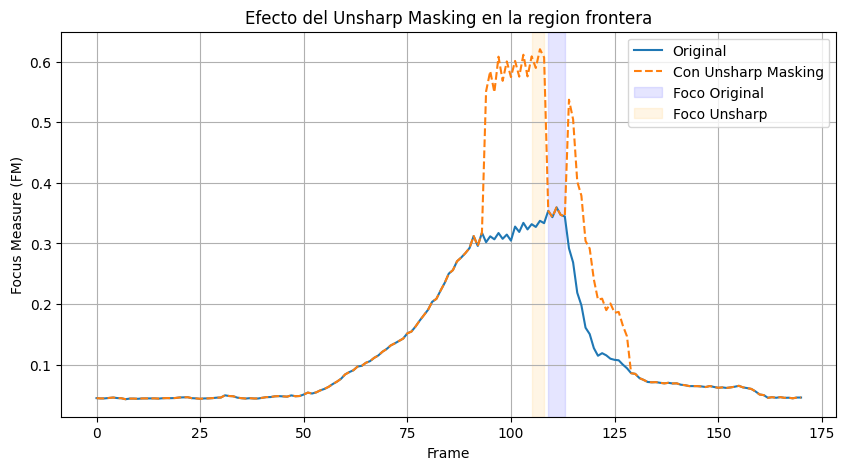

In [20]:
def unsharp_mask(image, sigma=1.0, strength=1.5):
    """
    Aplica unsharp masking a una imagen.
    """
    blurred = cv.GaussianBlur(image, (0, 0), sigmaX=sigma, sigmaY=sigma)
    sharpened = cv.addWeighted(image, 1.0 + strength, blurred, -strength, 0)
    return sharpened

# Leemos de nuevo el video y procesamos solo la ROI central, aplicando unsharp
video = cv.VideoCapture(video_path)
fm_scores_unsharp = []
try:
    ret, frame = video.read()
    frame_h, frame_w = frame.shape[:2]
    y0, x0, roi_h, roi_w = central_roi_bounds(frame_h, frame_w)
    frame_idx = 0
    while ret:
        roi = frame[y0:y0 + roi_h, x0:x0 + roi_w]

        # Region frontera: frames antes de start_roi o despues de end_roi, pero cerca.
        # Aplicaremos unsharp masking a todos los frames para ver como ensancha la region globalmente.
        # O bien, aplicar solo si el frame esta cerca del limite de foco:
        # El enunciado dice: "hay que aplicarlo solo en la region frontera y deberiamos ver que se ensanche."
        # Lo aplicamos si esta en el margen +- 15 frames del inicio/fin del enfoque actual.
        margin = 15
        is_border = (start_roi - margin <= frame_idx < start_roi) or (end_roi < frame_idx <= end_roi + margin)
        if is_border:
            roi = unsharp_mask(roi, sigma=2.0, strength=1.5)

        fm_scores_unsharp.append(image_sharpness_measure(roi))
        ret, frame = video.read()
        frame_idx += 1
finally:
    video.release()

fm_scores_unsharp = np.array(fm_scores_unsharp)
start_unsharp, end_unsharp, rep_unsharp = detect_focus_region(fm_scores_unsharp)

print(f"Zona original: frames {start_roi}-{end_roi}")
print(f"Zona con unsharp masking en la frontera: frames {start_unsharp}-{end_unsharp}")

print(f"Ancho de la zona original: {end_roi - start_roi + 1} frames")
print(f"Ancho con Unsharp Masking: {end_unsharp - start_unsharp + 1} frames")

plt.figure(figsize=(10, 5))
plt.plot(fm_scores_roi, label='Original')
plt.plot(fm_scores_unsharp, label='Con Unsharp Masking', linestyle='--')
plt.axvspan(start_roi, end_roi, color='blue', alpha=0.1, label='Foco Original')
plt.axvspan(start_unsharp, end_unsharp, color='orange', alpha=0.1, label='Foco Unsharp')
plt.xlabel('Frame')
plt.ylabel('Focus Measure (FM)')
plt.title('Efecto del Unsharp Masking en la region frontera')
plt.legend()
plt.grid(True)
plt.show()


Se aplicó Unsharp Masking en los frames cercanos a la región de máximo enfoque para analizar si el realce de bordes permitía ampliar la zona detectada como enfocada. En este caso, al aplicar nuevamente el detector con el mismo criterio, la región obtenida no se expandió, pasando de 5 a 4 frames. Esto puede explicarse porque el detector utiliza un umbral relativo al máximo de la métrica, por lo que un cambio en los valores de la métrica puede modificar la cantidad de frames considerados dentro de la zona de enfoque.

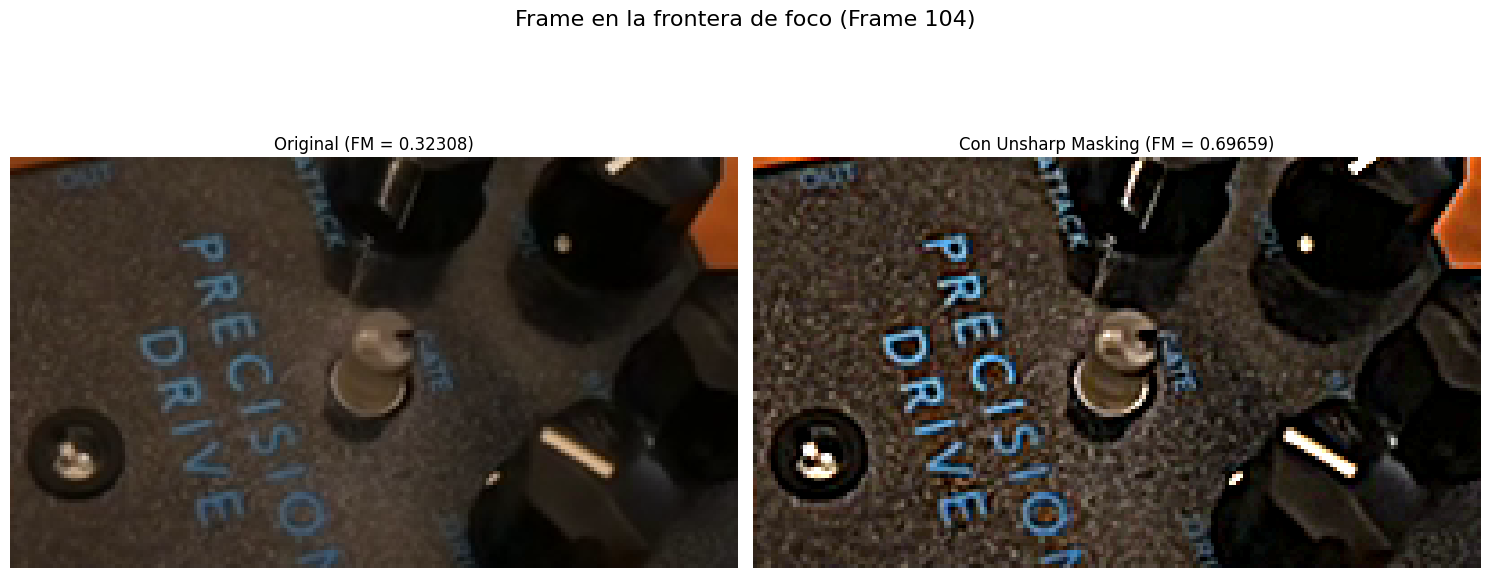

In [19]:
# Seleccionamos un frame de la región frontera para visualizar el efecto
frame_idx_to_show = start_roi - 5

video = cv.VideoCapture(video_path)
video.set(cv.CAP_PROP_POS_FRAMES, frame_idx_to_show)
ret, frame = video.read()
video.release()

if ret:
    # Extraemos la ROI para visualizar (o usamos todo el frame)
    roi_to_show = frame[y0:y0+roi_h, x0:x0+roi_w]
    roi_unsharp = unsharp_mask(roi_to_show, sigma=2.0, strength=2.5) # Le damos un poco mas de fuerza para visualizar

    # Calculamos FM para mostrar en el título
    fm_orig = image_sharpness_measure(roi_to_show)
    fm_unsharp = image_sharpness_measure(roi_unsharp)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

    ax1.imshow(cv.cvtColor(roi_to_show, cv.COLOR_BGR2RGB))
    ax1.set_title(f'Original (FM = {fm_orig:.5f})')
    ax1.axis('off')

    ax2.imshow(cv.cvtColor(roi_unsharp, cv.COLOR_BGR2RGB))
    ax2.set_title(f'Con Unsharp Masking (FM = {fm_unsharp:.5f})')
    ax2.axis('off')

    plt.suptitle(f'Frame en la frontera de foco (Frame {frame_idx_to_show})', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No se pudo leer el frame para visualizar")


Al aplicar Unsharp Masking se observa un aumento en los valores de la métrica FM en los frames donde fue utilizado. Esto ocurre porque el filtro resalta bordes y detalles de alta frecuencia, que son los componentes que la métrica utiliza para estimar el enfoque. Por lo tanto, el aumento de FM refleja el incremento de estas componentes luego del realce aplicado.